# IoTProber · 11 类设备识别最小展示案例

每类设备（`config/rag_devices.json` 的 11 个 RAG 类型）各取 **3 个识别效果最好的真实指纹**
（候选池 40/类，按 v2 adapter 的类型置信度排序取正确样本 Top-3），数据在 `demo/{TYPE}/cases.json`。

每个案例包含：完整指纹、adapter 分类结果（类型/厂商/置信度/novelty 概率）、
PACA drift 分数、以及 CAMERA 的向量近邻。本 notebook 展示静态结果（无需 GPU），
最后一节可选在线复跑。。

> 候选池已做三重排除：训练/验证集 IP、跨类型重复 IP（标签矛盾）、通用云主机（AWS/GCP 等）。
> 各类型的池大小与排除数见 `selection_summary.json`。

In [1]:
import json, os
def find_repo(start):
    d = os.path.abspath(start)
    for _ in range(4):
        if os.path.exists(os.path.join(d, 'config', 'rag_devices.json')):
            return d
        d = os.path.dirname(d)
    raise FileNotFoundError('config/rag_devices.json')
REPO = find_repo('.')
DEMO = os.path.join(REPO, 'demo')
types = json.load(open(os.path.join(REPO, 'config', 'rag_devices.json')))['IoT']
cases = {t: json.load(open(f'{DEMO}/{t}/cases.json')) for t in types if os.path.exists(f'{DEMO}/{t}/cases.json')}
summary = json.load(open(f'{DEMO}/selection_summary.json'))
print(f"{len(cases)} 类 × 每类 3 例 = {sum(len(v) for v in cases.values())} 个案例")

11 类 × 每类 3 例 = 33 个案例


## 1. 总览：每类候选池正确率与最高置信度

In [2]:
import pandas as pd
rows = []
for t, s in summary.items():
    r = cases[t][0]['result']
    rows.append({'类型': t, '候选': s['candidates'], '正确': s['correct'],
                 '正确率': round(s['correct']/s['candidates'], 3),
                 '最高类型置信度': round(s['top_conf'], 4),
                 '示例厂商': r['classified_vendor']})
df = pd.DataFrame(rows).sort_values('正确率', ascending=False).reset_index(drop=True)
df.style.background_gradient(subset=['正确率'], cmap='Blues').format({'正确率': '{:.1%}'})

,类型,候选,正确,正确率,最高类型置信度,示例厂商
0,ALARM,40,40,100.0%,0.999700,Bosch
1,NVR,40,40,100.0%,1.000000,Merit Lilin
2,CONTROLLER,40,40,100.0%,0.998700,Schneider Electric
3,POWER_METER,38,38,100.0%,0.999800,eGauge
4,SCADA,40,39,97.5%,0.999900,Hikvision
5,NAS,40,39,97.5%,0.999900,Synology
6,MEDICAL,40,39,97.5%,0.999900,Siemens
7,BUILDING_AUTOMATION,40,38,95.0%,0.999800,Bosch
8,PRINTER,40,37,92.5%,0.999900,Brother
9,CAMERA,40,36,90.0%,1.000000,Macroscopic


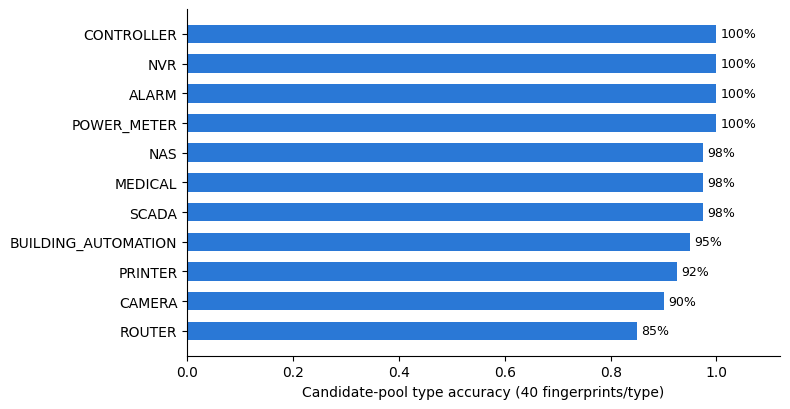

In [3]:
import matplotlib.pyplot as plt
d = df.sort_values('正确率')
fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.barh(d['类型'], d['正确率'], color='#2a78d6', height=0.62)
for b, v in zip(bars, d['正确率']):
    ax.text(v + 0.008, b.get_y() + b.get_height()/2, f'{v:.0%}', va='center', fontsize=9)
ax.set_xlim(0, 1.12); ax.set_xlabel('Candidate-pool type accuracy (40 fingerprints/type)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 2. 逐案例结果（类型 · 厂商 · 置信度 · novelty · drift）

In [4]:
rows = []
for t, cs in cases.items():
    for c in cs:
        r, dr = c['result'], c.get('drift', {})
        rows.append({'类型': t, 'IP': c['ip'],
                     '预测': f"{r['classified_type']} / {r['classified_vendor']}",
                     '类型置信度': round(r['type_confidence'], 4),
                     '厂商置信度': round(r['vendor_confidence'], 4),
                     'novelty(型/厂)': f"{r['new_type_probability']:.2f} / {r['new_vendor_probability']:.2f}",
                     'drift': dr.get('drift_score'), '漂移?': dr.get('is_drift')})
pd.DataFrame(rows)

,类型,IP,预测,类型置信度,厂商置信度,novelty(型/厂),drift,漂移?
0,NAS,86.194.248.180,NAS / Synology,0.9999,0.9985,0.00 / 0.00,1.1807,False
1,NAS,88.84.240.38,NAS / D-Link,0.9994,0.9999,0.00 / 0.00,22.5853,True
2,NAS,61.40.19.90,NAS / Hanwha,0.9551,0.9777,0.00 / 0.00,2.6714,False
3,NVR,109.81.182.57,NVR / Merit Lilin,1.0000,0.9362,0.00 / 0.00,2.3809,False
4,NVR,193.114.37.180,NVR / Huawei,1.0000,0.7607,0.00 / 0.00,5.4779,False
5,NVR,210.130.137.146,NVR / Hikvision,1.0000,0.9955,0.00 / 0.00,19.5382,True
6,POWER_METER,12.13.105.243,POWER_METER / eGauge,0.9998,0.9996,0.00 / 0.00,17.1045,True
7,POWER_METER,178.242.174.54,POWER_METER / Schneider Electric,0.9996,1.0000,0.00 / 0.00,14.3702,True
8,POWER_METER,63.46.75.110,POWER_METER / Sierra Wireless,0.9995,0.9904,0.00 / 0.00,24.7670,True
9,BUILDING_AUTOMATION,71.83.143.206,BUILDING_AUTOMATION / Bosch,0.9998,1.0000,0.00 / 0.00,6.2049,False


## 3. 单案例细看（可改 `T` / `i`）

指纹的 11 视角中，证书 / 硬件 / 软件 / favicon 是高权重判别位。

In [5]:
T, i = 'CAMERA', 0
c = cases[T][i]
print(f"IP {c['ip']}  →  {c['result']['classified_type']} / {c['result']['classified_vendor']}"
      f"  (type_conf={c['result']['type_confidence']:.4f})")
print(f"drift score={c['drift'].get('drift_score')} (τ=8.78, is_drift={c['drift'].get('is_drift')})")
if 'local_retrieval_neighbours' in c:
    print('向量近邻:', [(n['ip'], n['similarity']) for n in c['local_retrieval_neighbours'][:3]])
fp = c['fingerprint']
for k in ['cert-subjects','hw-vendors','hw-products','sw-vendors','os-vendor','http-info','dns-reverse']:
    if fp.get(k): print(f"  {k:14}: {str(fp[k])[:90]}")

IP 46.20.187.135  →  CAMERA / Macroscopic  (type_conf=1.0000)
drift score=12.8116 (τ=8.78, is_drift=True)
向量近邻: [('202.82.81.19', 0.6909), ('75.205.240.185', 0.6907), ('49.128.162.163', 0.688)]
  cert-subjects : CN=*.arriah.ru
  hw-vendors    : Unknown
  hw-products   : Unknown
  sw-vendors    : Unknown,openbsd,f5,f5
  os-vendor     : canonical
  http-info     : HTTP-3189: (html body: {endpoint0: <!doctype html><html lang="ru"><head><meta charset="UTF


## 4.（可选）在线复跑

需 GPU 与 iotprober 环境；结果应与存储值一致（确定性解码）。也可用 Web 界面：
`cd demo && python app.py` → http://localhost:5001

In [6]:
# import sys; sys.path.insert(0, '..'); sys.path.insert(0, '../agent')
# from unseen import UnseenDeviceDetector
# from util import build_fingerprint_info_text, build_unseen_type_vendor_classification_prompt
# det = UnseenDeviceDetector(adapter_path='../evaluation/unseen/llama3/results_v2/final_model',
#                            gpu=0, load_in_4bit=True)
# c = cases['CAMERA'][0]
# prompt = build_unseen_type_vendor_classification_prompt(
#     build_fingerprint_info_text(c['fingerprint']), det.rag_devices, det.known_vendors_by_type)
# text, conf = det._generate_classification(prompt)
# print(det._classification_novelty_result(det._parse_response(text), conf))